##### Copyright 2026 Google LLC.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Multimodal semantic search with gemini-embedding-2

Author: [@NaveenKumarG-dev](https://github.com/NaveenKumarG-dev)

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Multimodal_Semantic_Search_gemini_embedding_2.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

This notebook demonstrates multimodal semantic search and cross-modal retrieval using the `gemini-embedding-2` model and the official `google-genai` Python SDK.

You will learn how to:

1. **Set up** the `google-genai` SDK and authenticate with your API key.
2. **Build a mixed dataset** with intentionally misleading filenames to highlight the power of semantic search.
3. **Load files** of different types and prepare them for embedding generation.
4. **Generate multimodal embeddings** for both text and image content using `gemini-embedding-2`.
5. **Perform semantic similarity search** using cosine similarity.
6. **Run cross-modal retrieval** with natural language queries.
7. **Visualize** the retrieved results and compare semantic search with keyword search.

Check the [pricing page](https://ai.google.dev/pricing) and the [model documentation](https://ai.google.dev/gemini-api/docs/embeddings) for the latest details.

## Setup

### Install the SDK

In [2]:
%pip install -U -q "google-genai>=1.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.6/258.6 kB 22.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.56.2 which is incompatible.


### Set up your API key

To run the following cell, your API key must be stored in a Colab Secret named `GEMINI_API_KEY`. If you don't already have an API key, or you're not sure how to create a Colab Secret, see the [Authentication](../quickstarts/Authentication.ipynb) quickstart for a walkthrough.

In [3]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=GEMINI_API_KEY)

### Select the embedding model

You will use `gemini-embedding-2`, which maps text and images into a shared vector space, enabling cross-modal comparisons.

In [4]:
EMBEDDING_MODEL = "gemini-embedding-2"  # @param ["gemini-embedding-2"] {"allow-input": true, isTemplate: true}

### Import libraries

In [5]:
import os
import mimetypes
import numpy as np

from PIL import Image
from typing import Any
from IPython.display import display, HTML

## Build the dataset

To highlight the power of semantic search, you will create a small local dataset with **intentionally misleading filenames**. For example, an image of a dog is saved as `cat_image.png`, while a text file about the ocean is named `space_facts.txt`.

A traditional keyword search for "cat" would find `cat_image.png` because of its name. Semantic search, however, analyses the content itself — so querying for "dog" correctly retrieves `cat_image.png` because its content is a dog.

The images below are sourced from [Wikimedia Commons](https://commons.wikimedia.org/) and are licensed under Creative Commons (CC-BY-SA or similar). See the individual Wikimedia Commons file pages for exact licensing details. The text documents are original content.

In [6]:
import requests

DATA_DIR = "multimodal_data"
os.makedirs(DATA_DIR, exist_ok=True)

# Publicly accessible, stable image URLs (Wikimedia Commons, CC0/public domain)
DATASET = [
    {
        "filename": "cat_image.png",       # Misleading: actually a dog
        "content_type": "image",
        "true_label": "dog",
        "image_url": "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg",
    },
    {
        "filename": "dog_picture.jpg",      # Misleading: actually a cat
        "content_type": "image",
        "true_label": "cat",
        "image_url": "https://upload.wikimedia.org/wikipedia/commons/1/11/Fluffy_Cat.jpg",
    },
    {
        "filename": "ocean_view.jpg",       # Misleading: actually a mountain
        "content_type": "image",
        "true_label": "mountain",
        "image_url": "https://upload.wikimedia.org/wikipedia/commons/e/e7/Everest_North_Face_toward_Base_Camp_Tibet_Luca_Galuzzi_2006.jpg",
    },
    {
        "filename": "space_facts.txt",      # Misleading: actually about the ocean
        "content_type": "text",
        "true_label": "ocean",
        "text_content": (
            "The ocean covers more than 70% of the Earth's surface. "
            "It is home to a vast diversity of marine life, from microscopic "
            "plankton to giant whales. The deepest point, the Mariana Trench, "
            "plunges nearly 11 kilometres below the surface."
        ),
    },
    {
        "filename": "mountain_climbing.txt", # Misleading: actually about stars
        "content_type": "text",
        "true_label": "stars",
        "text_content": (
            "The night sky is filled with billions of stars, planets, and galaxies. "
            "On a clear night, away from city lights, you can observe the Milky Way "
            "arching across the sky. Constellations like Orion and the Big Dipper "
            "have guided navigators for centuries."
        ),
    },
    {
        "filename": "bird_song.txt",        # Misleading: actually about a car
        "content_type": "text",
        "true_label": "car",
        "text_content": (
            "The sleek red sports car accelerated down the coastal road, "
            "its powerful engine a symphony of finely tuned machinery. "
            "It hugged every curve effortlessly, a blur of speed against the deep blue sea."
        ),
    },
]


def download_image(url: str, filename: str) -> None:
    """Downloads an image from a URL and saves it to DATA_DIR."""
    dest = os.path.join(DATA_DIR, filename)
    # Wikimedia Commons requires a User-Agent header to prevent 403 blocks
    headers = {
        "User-Agent": "GeminiAPICookbook/1.0 (https://github.com/google-gemini/cookbook)"
    }
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()
    with open(dest, "wb") as f:
        f.write(response.content)
    print(f"Downloaded  {filename}")


# Create the dataset files
for item in DATASET:
    file_path = os.path.join(DATA_DIR, item["filename"])
    if item["content_type"] == "image":
        if not os.path.exists(file_path):
            download_image(item["image_url"], item["filename"])
        else:
            print(f"Already exists: {item['filename']}")
    else:
        if not os.path.exists(file_path):
            with open(file_path, "w", encoding="utf-8") as f:
                f.write(item["text_content"])
            print(f"Created       {item['filename']}")
        else:
            print(f"Already exists: {item['filename']}")

print(f"\nDataset ready in '{DATA_DIR}/'")

Downloaded  cat_image.png
Downloaded  dog_picture.jpg
Downloaded  ocean_view.jpg
Created       space_facts.txt
Created       mountain_climbing.txt
Created       bird_song.txt

Dataset ready in 'multimodal_data/'


## Load files

Load each file and detect its MIME type. Images are opened as `PIL.Image` objects; text files are read as plain strings.

In [7]:
# @title Helper — guess_mime_type and load_file_content

def guess_mime_type(file_path: str) -> str:
    """Guess the MIME type of a file with a robust fallback mapping."""
    mime_type, _ = mimetypes.guess_type(file_path)
    if not mime_type:
        ext = os.path.splitext(file_path)[1].lower()
        if ext in [".png", ".webp", ".bmp", ".gif"]:
            mime_type = f"image/{ext[1:]}"
        elif ext in [".jpg", ".jpeg"]:
            mime_type = "image/jpeg"
        elif ext in [".txt", ".md", ".py", ".json", ".csv"]:
            mime_type = "text/plain"
        else:
            mime_type = "application/octet-stream"
    return mime_type


def load_file_content(file_path: str) -> str | Image.Image:
    """Loads file content based on its MIME type.

    Args:
        file_path: Path to the file.

    Returns:
        A str for text files, or a PIL.Image.Image for image files.

    Raises:
        FileNotFoundError: If the file does not exist.
        ValueError: If the MIME type is not supported.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    mime_type = guess_mime_type(file_path)

    if mime_type.startswith("image"):
        return Image.open(file_path).convert("RGB")
    elif mime_type.startswith("text"):
        with open(file_path, "r", encoding="utf-8") as f:
            return f.read()
    else:
        raise ValueError(
            f"Unsupported MIME type '{mime_type}' for file: {file_path}"
        )

In [8]:
loaded_files = []

print(f"Loading files from '{DATA_DIR}/'...")
for root, _, filenames in os.walk(DATA_DIR):
    for filename in sorted(filenames):
        file_path = os.path.join(root, filename)
        mime_type = guess_mime_type(file_path)
        try:
            content = load_file_content(file_path)
            loaded_files.append(
                {
                    "filename": filename,
                    "path": file_path,
                    "mime_type": mime_type,
                    "content": content,
                }
            )
            print(f"  Loaded {filename} ({mime_type})")
        except (FileNotFoundError, ValueError) as e:
            print(f"  Skipped {filename}: {e}")

print(f"\nTotal files loaded: {len(loaded_files)}")

Loading files from 'multimodal_data/'...
  Loaded bird_song.txt (text/plain)
  Loaded cat_image.png (image/png)
  Loaded dog_picture.jpg (image/jpeg)
  Loaded mountain_climbing.txt (text/plain)
  Loaded ocean_view.jpg (image/jpeg)
  Loaded space_facts.txt (text/plain)

Total files loaded: 6


## Generate embeddings

Use `client.models.embed_content` to generate a vector for each file.

The `gemini-embedding-2` model is multimodal. For retrieval-related use cases, the model relies on structured **task prefixes** in the inputs to bridge the asymmetry between queries and documents.

Best practices for formatting inputs:

- **Search Query** — Prefix the query with: `task: search result | query: {query_text}`
- **Text Document** — Format as: `title: {filename} | text: {document_content}`
- **Image Document** — Interleave a text part containing `title: {filename} | text: ` followed by the image bytes part (obtained using `types.Part.from_bytes(...)`).

In [9]:
# @title Helper — generate_embedding

from google.genai import types as genai_types


def generate_embedding(
    content: str | bytes,
    mime_type: str | None = None,
    is_query: bool = False,
    title: str | None = None,
) -> list[float]:
    """Generates an embedding vector for text or image content.

    Args:
        content: A text string or raw bytes (for images).
        mime_type: The MIME type of the content (required if content is bytes).
        is_query: True if generating embedding for a search query.
        title: The document title/filename (used for documents).

    Returns:
        A list of floats representing the embedding vector.

    Note:
        For real applications, consider using a library like numpy to handle vector arithmetic.
    """
    if is_query:
        # Format the query according to gemini-embedding-2 best practices
        input_content = f"task: search result | query: {content}"
    else:
        doc_title = title if title else "none"
        if isinstance(content, bytes):
            if not mime_type:
                raise ValueError("mime_type is required for binary content (bytes)")
            # Interleave document title prefix with the image part
            input_content = [
                f"title: {doc_title} | text: ",
                genai_types.Part.from_bytes(
                    data=content,
                    mime_type=mime_type,
                )
            ]
        else:
            # Format text document with title and content
            input_content = f"title: {doc_title} | text: {content}"

    response = client.models.embed_content(
        model=EMBEDDING_MODEL,
        contents=input_content,
    )
    return response.embeddings[0].values

In [10]:
# Build the indexed corpus by generating an embedding for each file.
indexed_corpus = []

print("Generating embeddings...")
for item in loaded_files:
    try:
        if item["mime_type"].startswith("image"):
            # Read binary file bytes for image embeddings
            with open(item["path"], "rb") as f:
                embed_data = f.read()
            mime_type = item["mime_type"]
        else:
            # Use plain string for text embeddings
            embed_data = item["content"]
            mime_type = None

        embedding = generate_embedding(
            embed_data,
            mime_type=mime_type,
            is_query=False,
            title=item["filename"],
        )
        indexed_corpus.append(
            {
                "filename": item["filename"],
                "path": item["path"],
                "mime_type": item["mime_type"],
                "content_type": "image" if item["mime_type"].startswith("image") else "text",
                "content": item["content"],
                "embedding": embedding,
            }
        )
        print(f"  Embedded {item['filename']}")
    except Exception as e:  # pylint: disable=broad-except
        print(f"  Error embedding {item['filename']}: {e}")

print(f"\nCorpus size: {len(indexed_corpus)} items")

Generating embeddings...
  Embedded bird_song.txt
  Embedded cat_image.png
  Embedded dog_picture.jpg
  Embedded mountain_climbing.txt
  Embedded ocean_view.jpg
  Embedded space_facts.txt

Corpus size: 6 items


## Search the corpus

Define the similarity function and search helper. Cosine similarity measures the angle between two vectors — values closer to 1.0 indicate higher semantic similarity.

In [11]:
# @title Helper — cosine_similarity and search_similar_content


def cosine_similarity(vec1: list[float], vec2: list[float]) -> float:
    """Returns the cosine similarity between two embedding vectors."""
    # Since gemini-embedding-2 vectors are normalized unit vectors,
    # cosine similarity simplifies to the dot product.
    return float(np.dot(vec1, vec2))


def search_similar_content(
    query_text: str,
    corpus: list[dict[str, Any]],
    top_k: int = 3,
) -> list[dict[str, Any]]:
    """Performs semantic search against the indexed corpus.

    Args:
        query_text: The natural language query.
        corpus: The list of embedded items.
        top_k: Number of top results to return.

    Returns:
        A list of the top_k most similar items, sorted by score descending.
    """
    # Embed the query with the is_query=True flag
    query_embedding = generate_embedding(query_text, is_query=True)

    scored = [
        {
            **{k: v for k, v in item.items() if k != "embedding"},
            "score": cosine_similarity(query_embedding, item["embedding"]),
        }
        for item in corpus
    ]
    scored.sort(key=lambda x: x["score"], reverse=True)
    return scored[:top_k]

## Run cross-modal retrieval

Run several text queries against the corpus. Notice that the results are ranked heavily by semantic content. While document titles are still factored in by the model, semantic alignment often outweighs misleading filenames.

In [12]:
queries = [
    "a dog running in a field",
    "a fluffy cat resting",
    "beautiful mountain scenery",
    "a starry night sky",
    "the vast ocean and marine life",
    "a fast sports car",
]

retrieval_results: dict[str, list[dict[str, Any]]] = {}

for query in queries:
    print(f"\nQuery: '{query}'")
    results = search_similar_content(query, indexed_corpus, top_k=3)
    retrieval_results[query] = results
    for rank, result in enumerate(results, start=1):
        print(
            f"  {rank}. {result['filename']} "
            f"(type={result['content_type']}, score={result['score']:.4f})"
        )


Query: 'a dog running in a field'
  1. cat_image.png (type=image, score=0.6710)
  2. bird_song.txt (type=text, score=0.6121)
  3. dog_picture.jpg (type=image, score=0.6111)

Query: 'a fluffy cat resting'
  1. dog_picture.jpg (type=image, score=0.6800)
  2. cat_image.png (type=image, score=0.6499)
  3. bird_song.txt (type=text, score=0.5920)

Query: 'beautiful mountain scenery'
  1. ocean_view.jpg (type=image, score=0.6784)
  2. mountain_climbing.txt (type=text, score=0.6717)
  3. bird_song.txt (type=text, score=0.6046)

Query: 'a starry night sky'
  1. mountain_climbing.txt (type=text, score=0.7686)
  2. space_facts.txt (type=text, score=0.5984)
  3. bird_song.txt (type=text, score=0.5972)

Query: 'the vast ocean and marine life'
  1. space_facts.txt (type=text, score=0.7908)
  2. mountain_climbing.txt (type=text, score=0.6470)
  3. bird_song.txt (type=text, score=0.6136)

Query: 'a fast sports car'
  1. bird_song.txt (type=text, score=0.7794)
  2. cat_image.png (type=image, score=0.5

## Visualize results

Display the retrieved items for each query. Images are shown inline; text results show a snippet of their content.

In [13]:
# @title Helper — display_results

import base64
import io


def pil_to_data_uri(img: Image.Image, fmt: str = "JPEG") -> str:
    """Converts a PIL image to a base64 data URI for inline HTML display."""
    buf = io.BytesIO()
    img.save(buf, format=fmt)
    encoded = base64.b64encode(buf.getvalue()).decode("utf-8")
    return f"data:image/{fmt.lower()};base64,{encoded}"


def display_results(
    query: str,
    results: list[dict[str, Any]],
) -> None:
    """Renders retrieval results as an HTML card grid."""
    cards = ""
    for rank, result in enumerate(results, start=1):
        if result["content_type"] == "image":
            data_uri = pil_to_data_uri(result["content"])
            media_html = (
                f"<img src='{data_uri}' "
                "style='max-width:100%;height:180px;object-fit:cover;"
                "border-radius:4px;'>"
            )
        else:
            snippet = result["content"][:200]
            if len(result["content"]) > 200:
                snippet += "..."
            media_html = (
                "<div style='background:#f5f5f5;color:#333;padding:8px;"
                "border-radius:4px;font-size:0.85em;max-height:160px;"
                f"overflow-y:auto;'><code>{snippet}</code></div>"
            )

        cards += f"""
        <div style='border:1px solid #ddd;border-radius:8px;padding:12px;
                    width:280px;box-shadow:0 1px 4px rgba(0,0,0,.1);'>
          <b>#{rank} &mdash; score: {result['score']:.4f}</b><br>
          <small><code>{result['filename']}</code> ({result['content_type']})</small>
          <div style='margin-top:8px;'>{media_html}</div>
        </div>"""

    html = f"""
    <h3 style='margin-bottom:8px;'>Query: &ldquo;{query}&rdquo;</h3>
    <div style='display:flex;flex-wrap:wrap;gap:16px;margin-bottom:24px;'>
      {cards}
    </div>"""
    display(HTML(html))


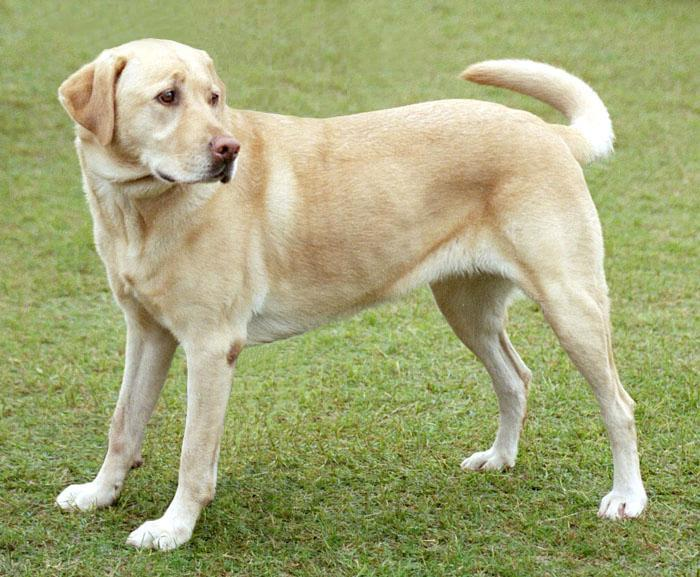
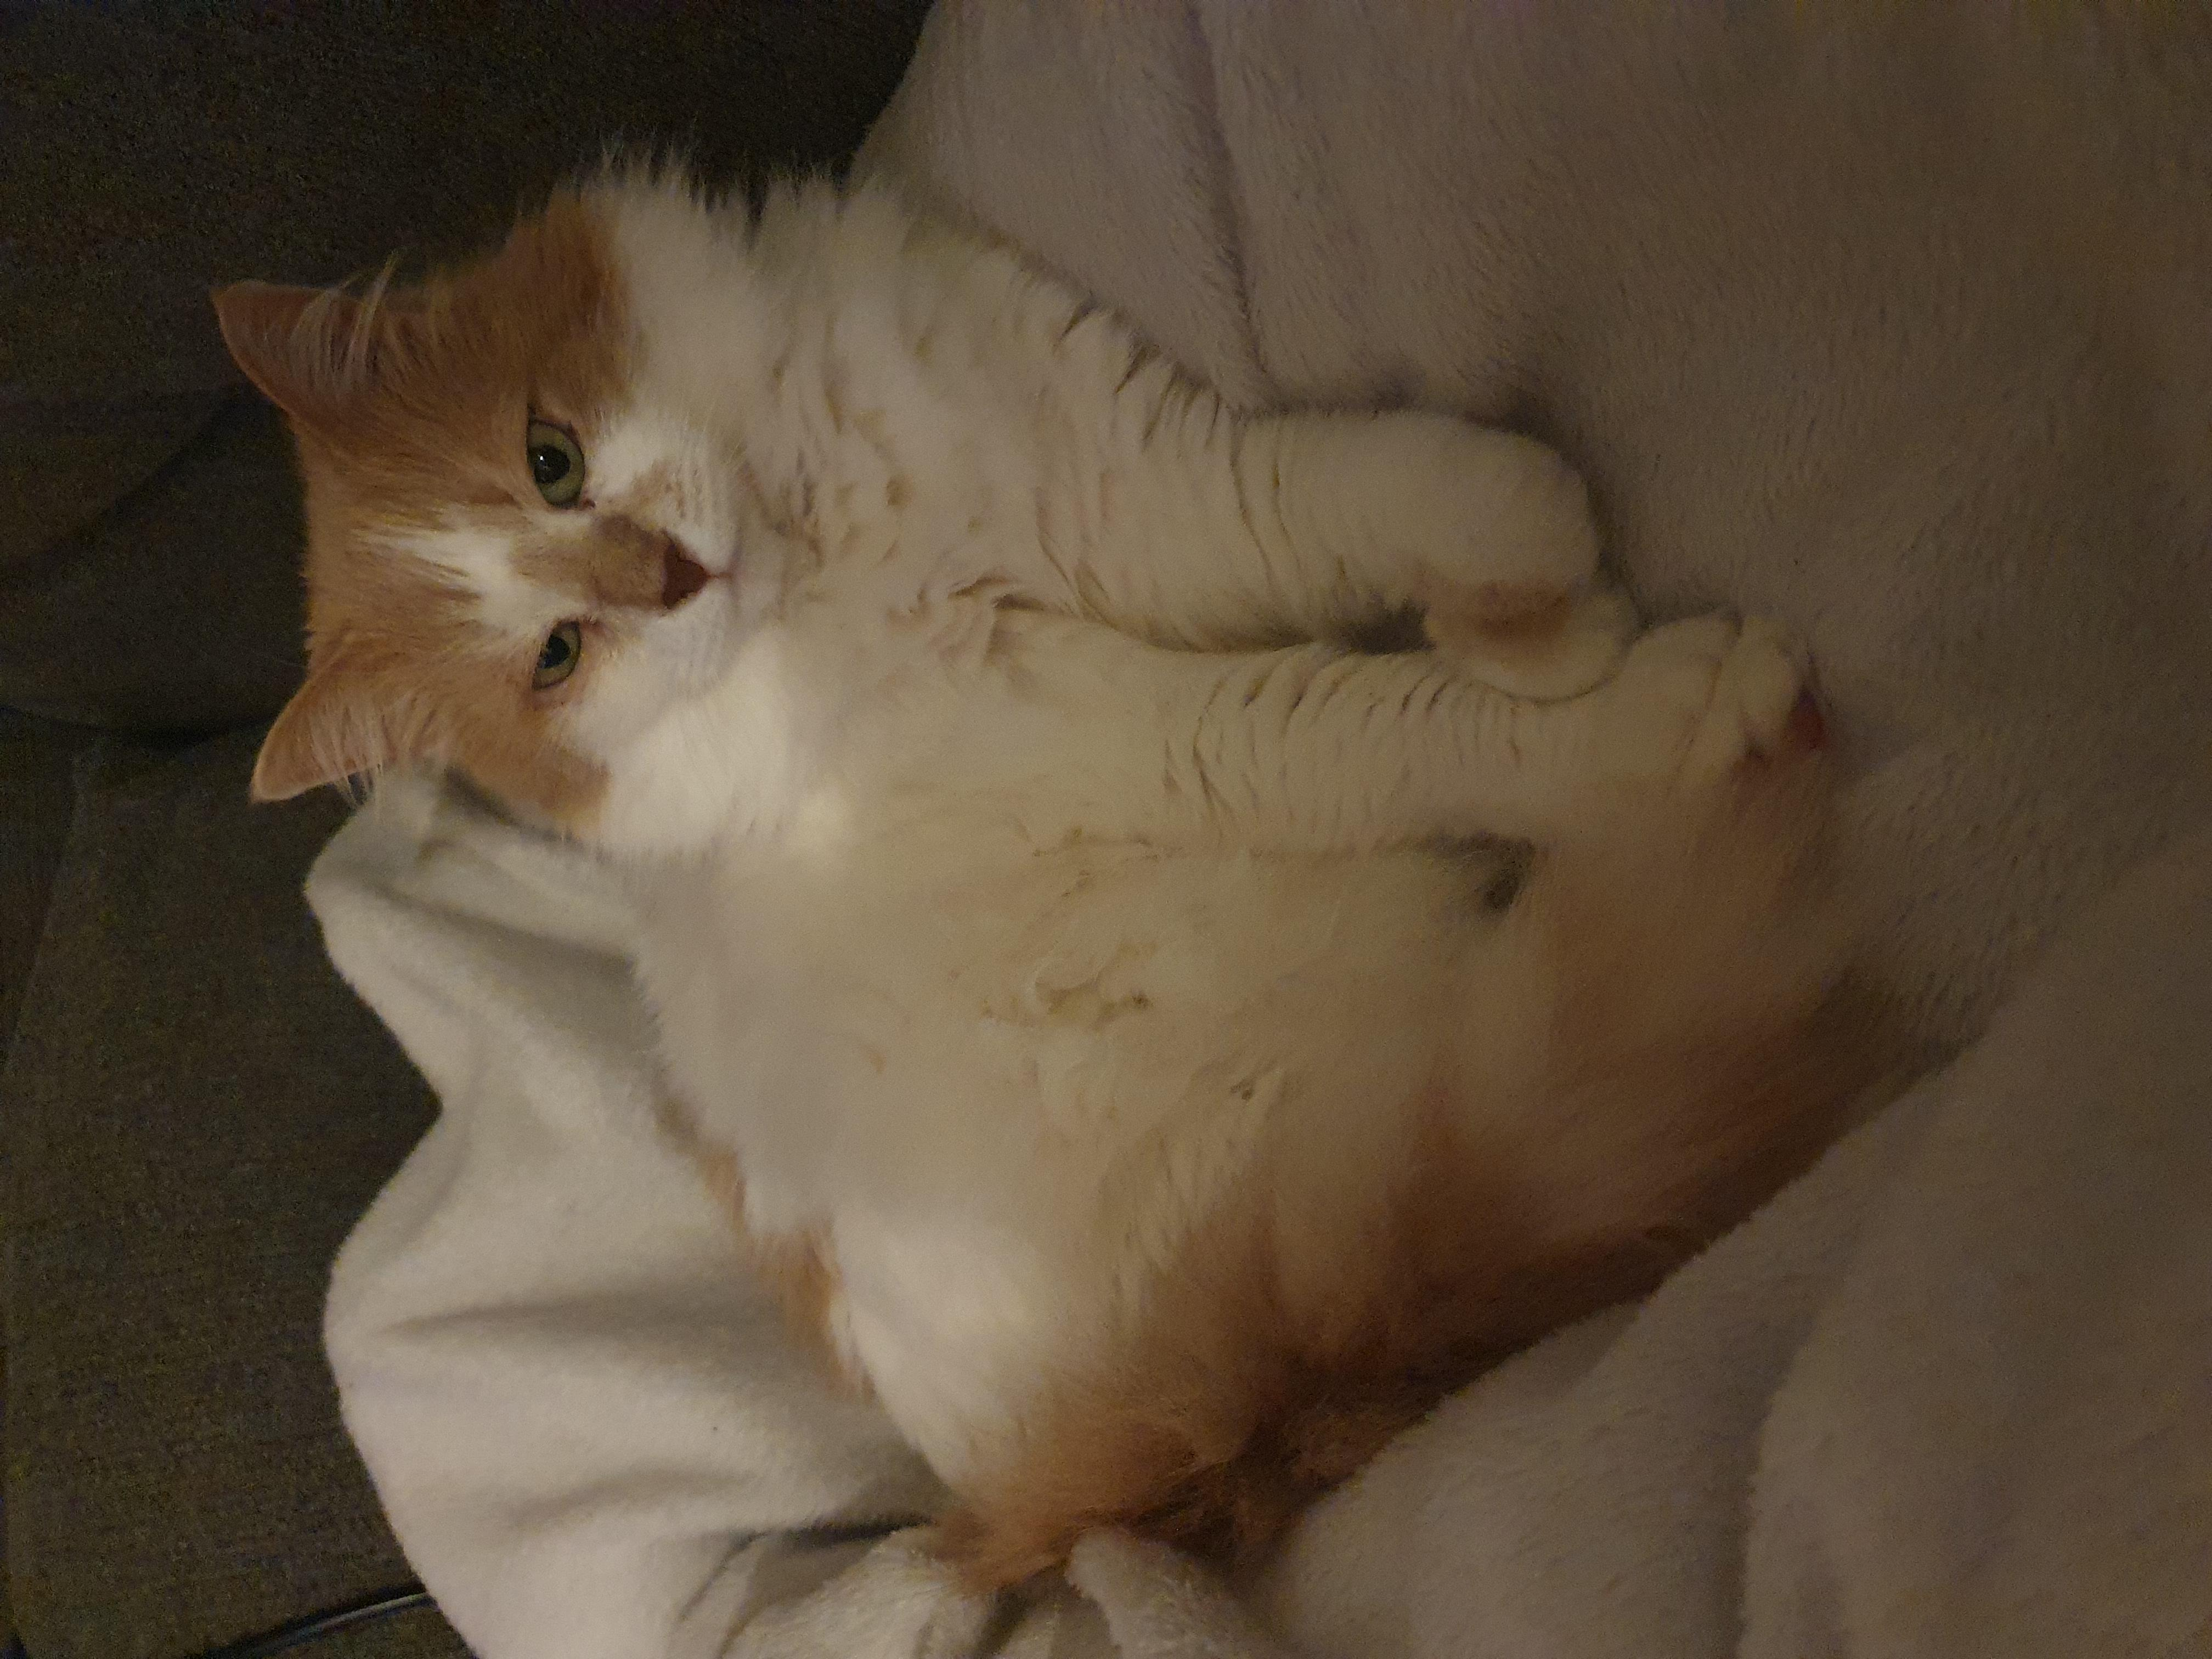


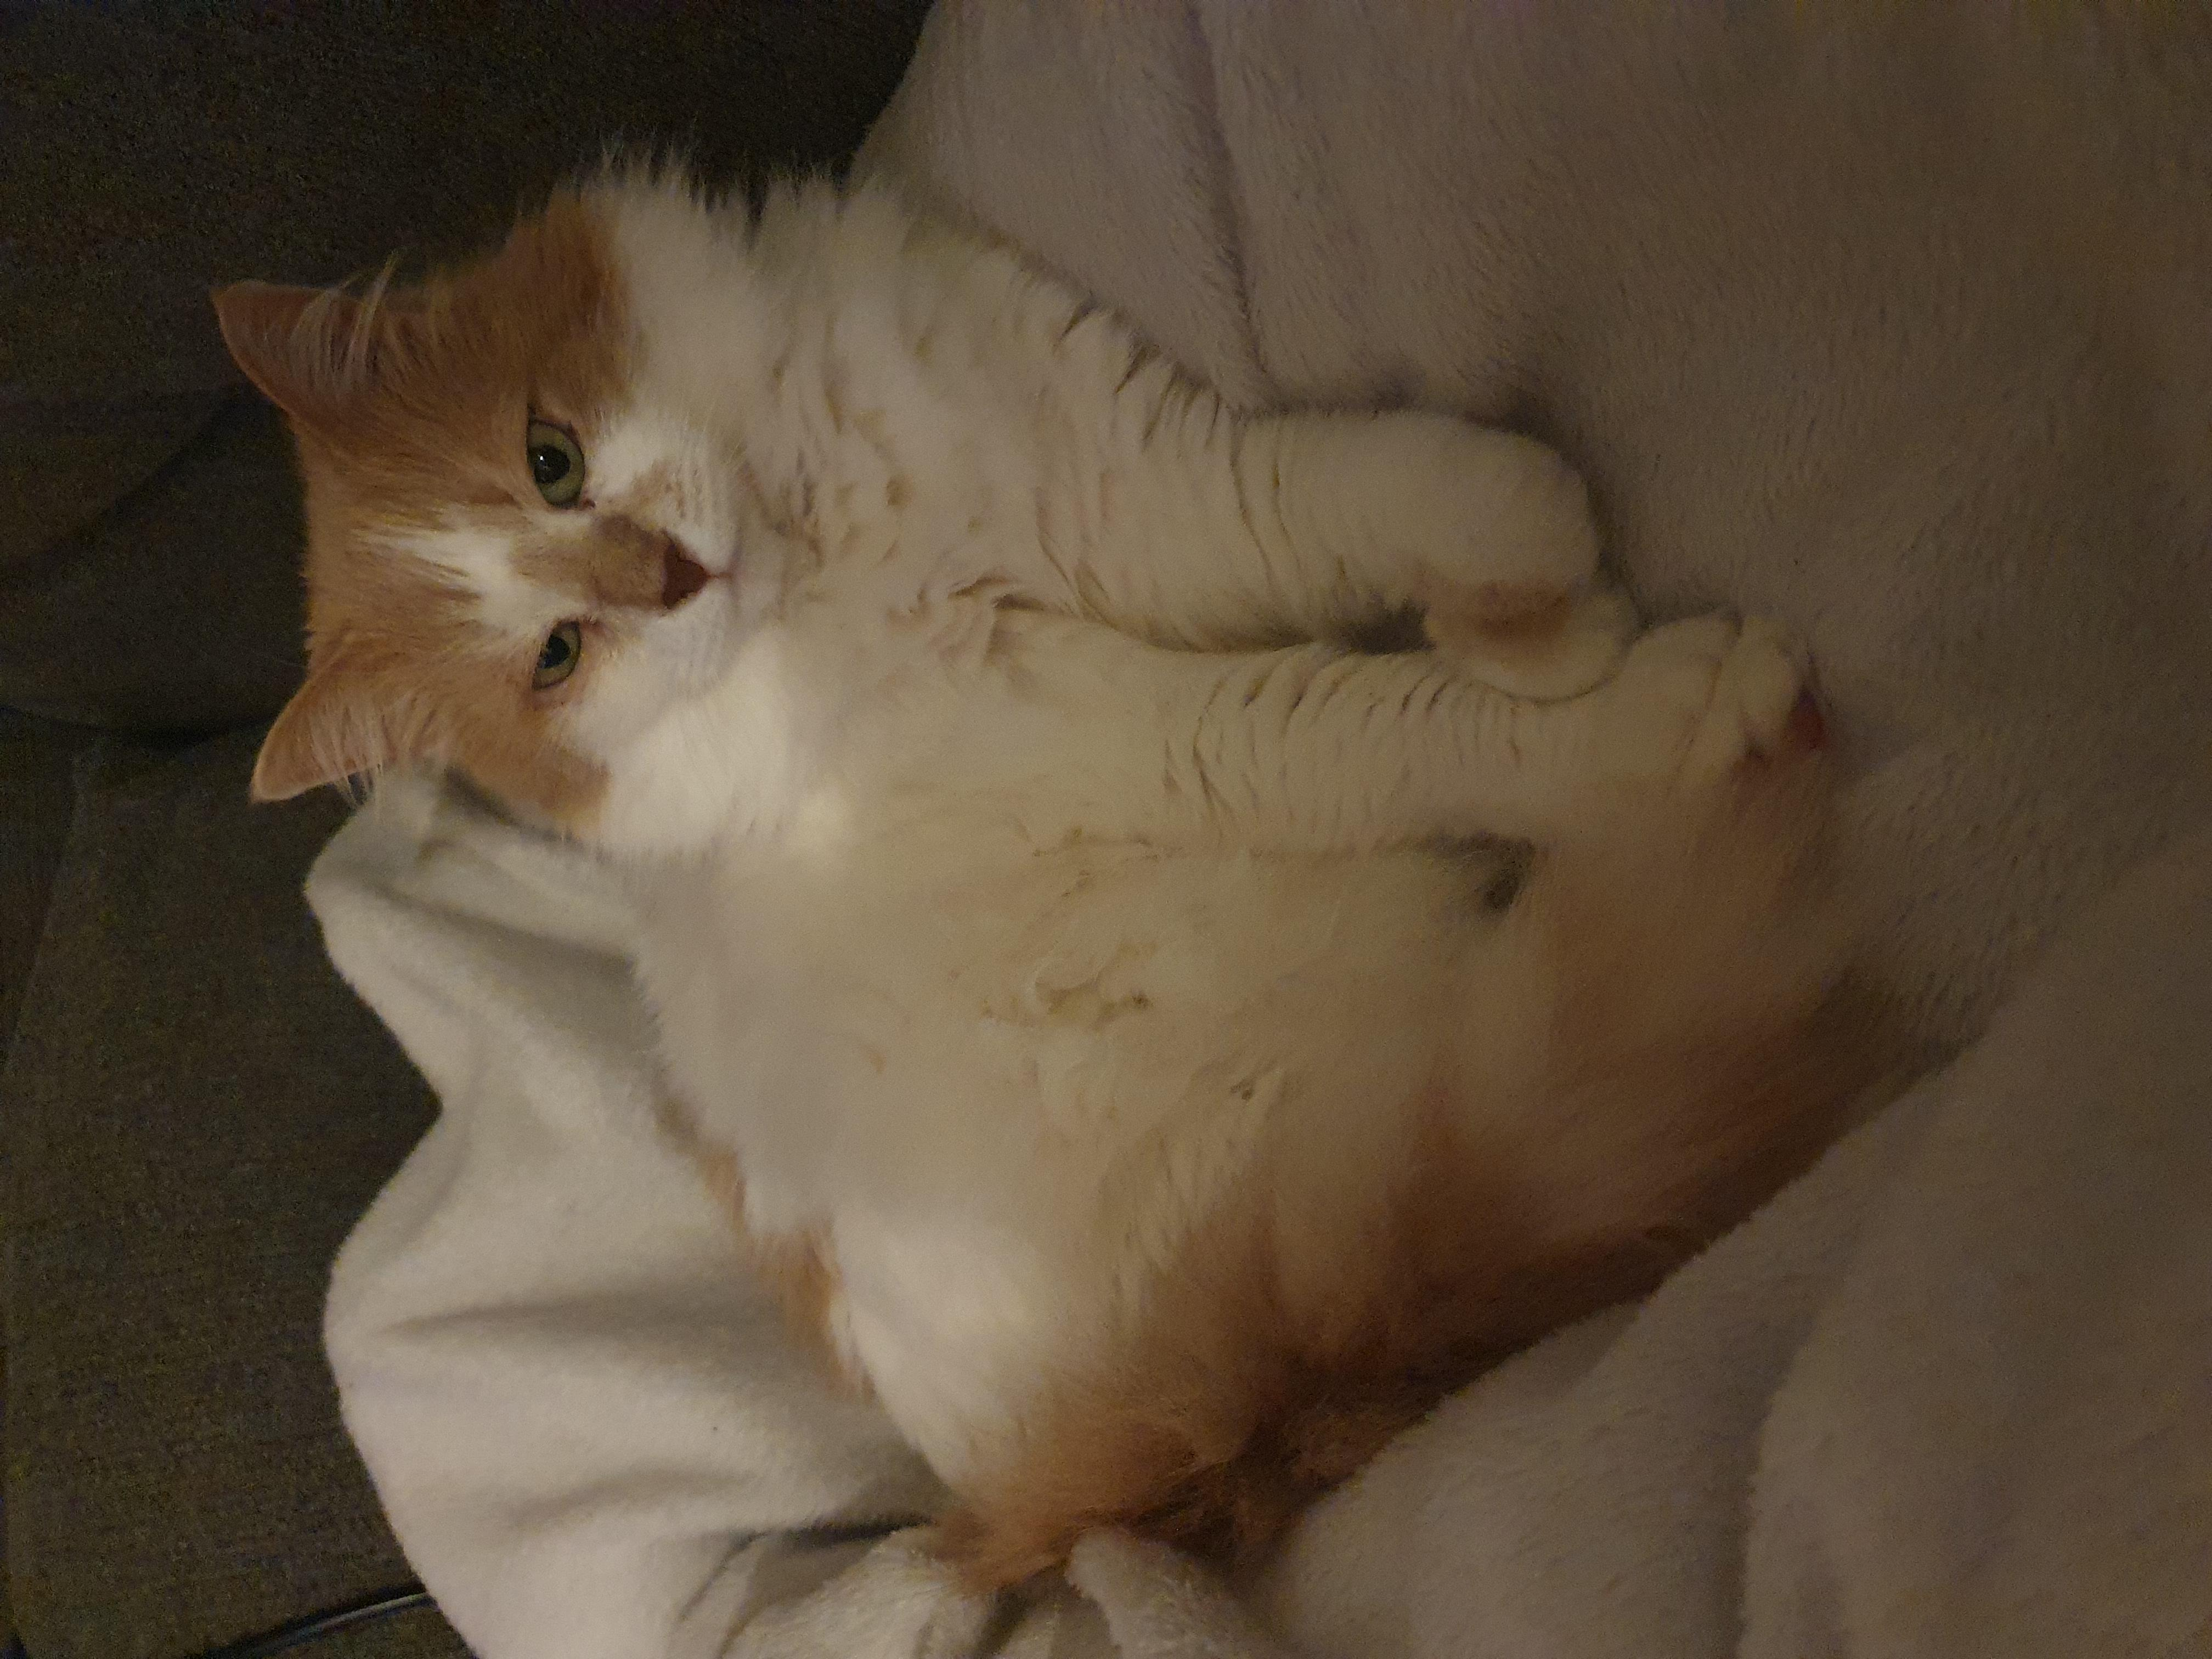
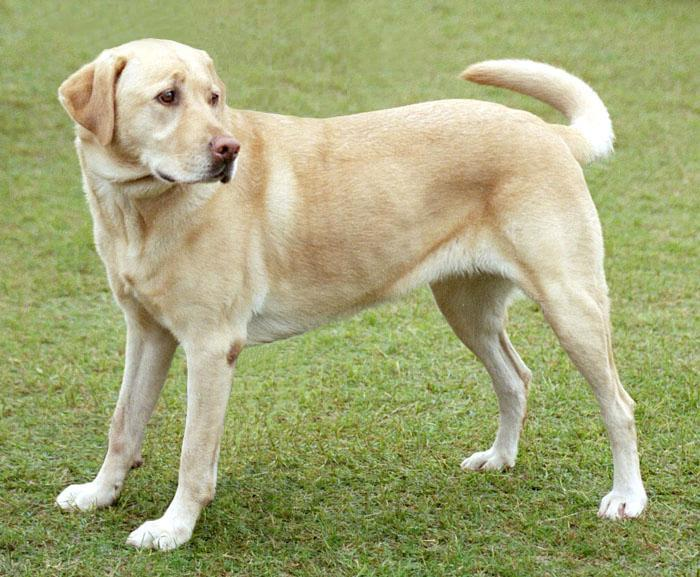


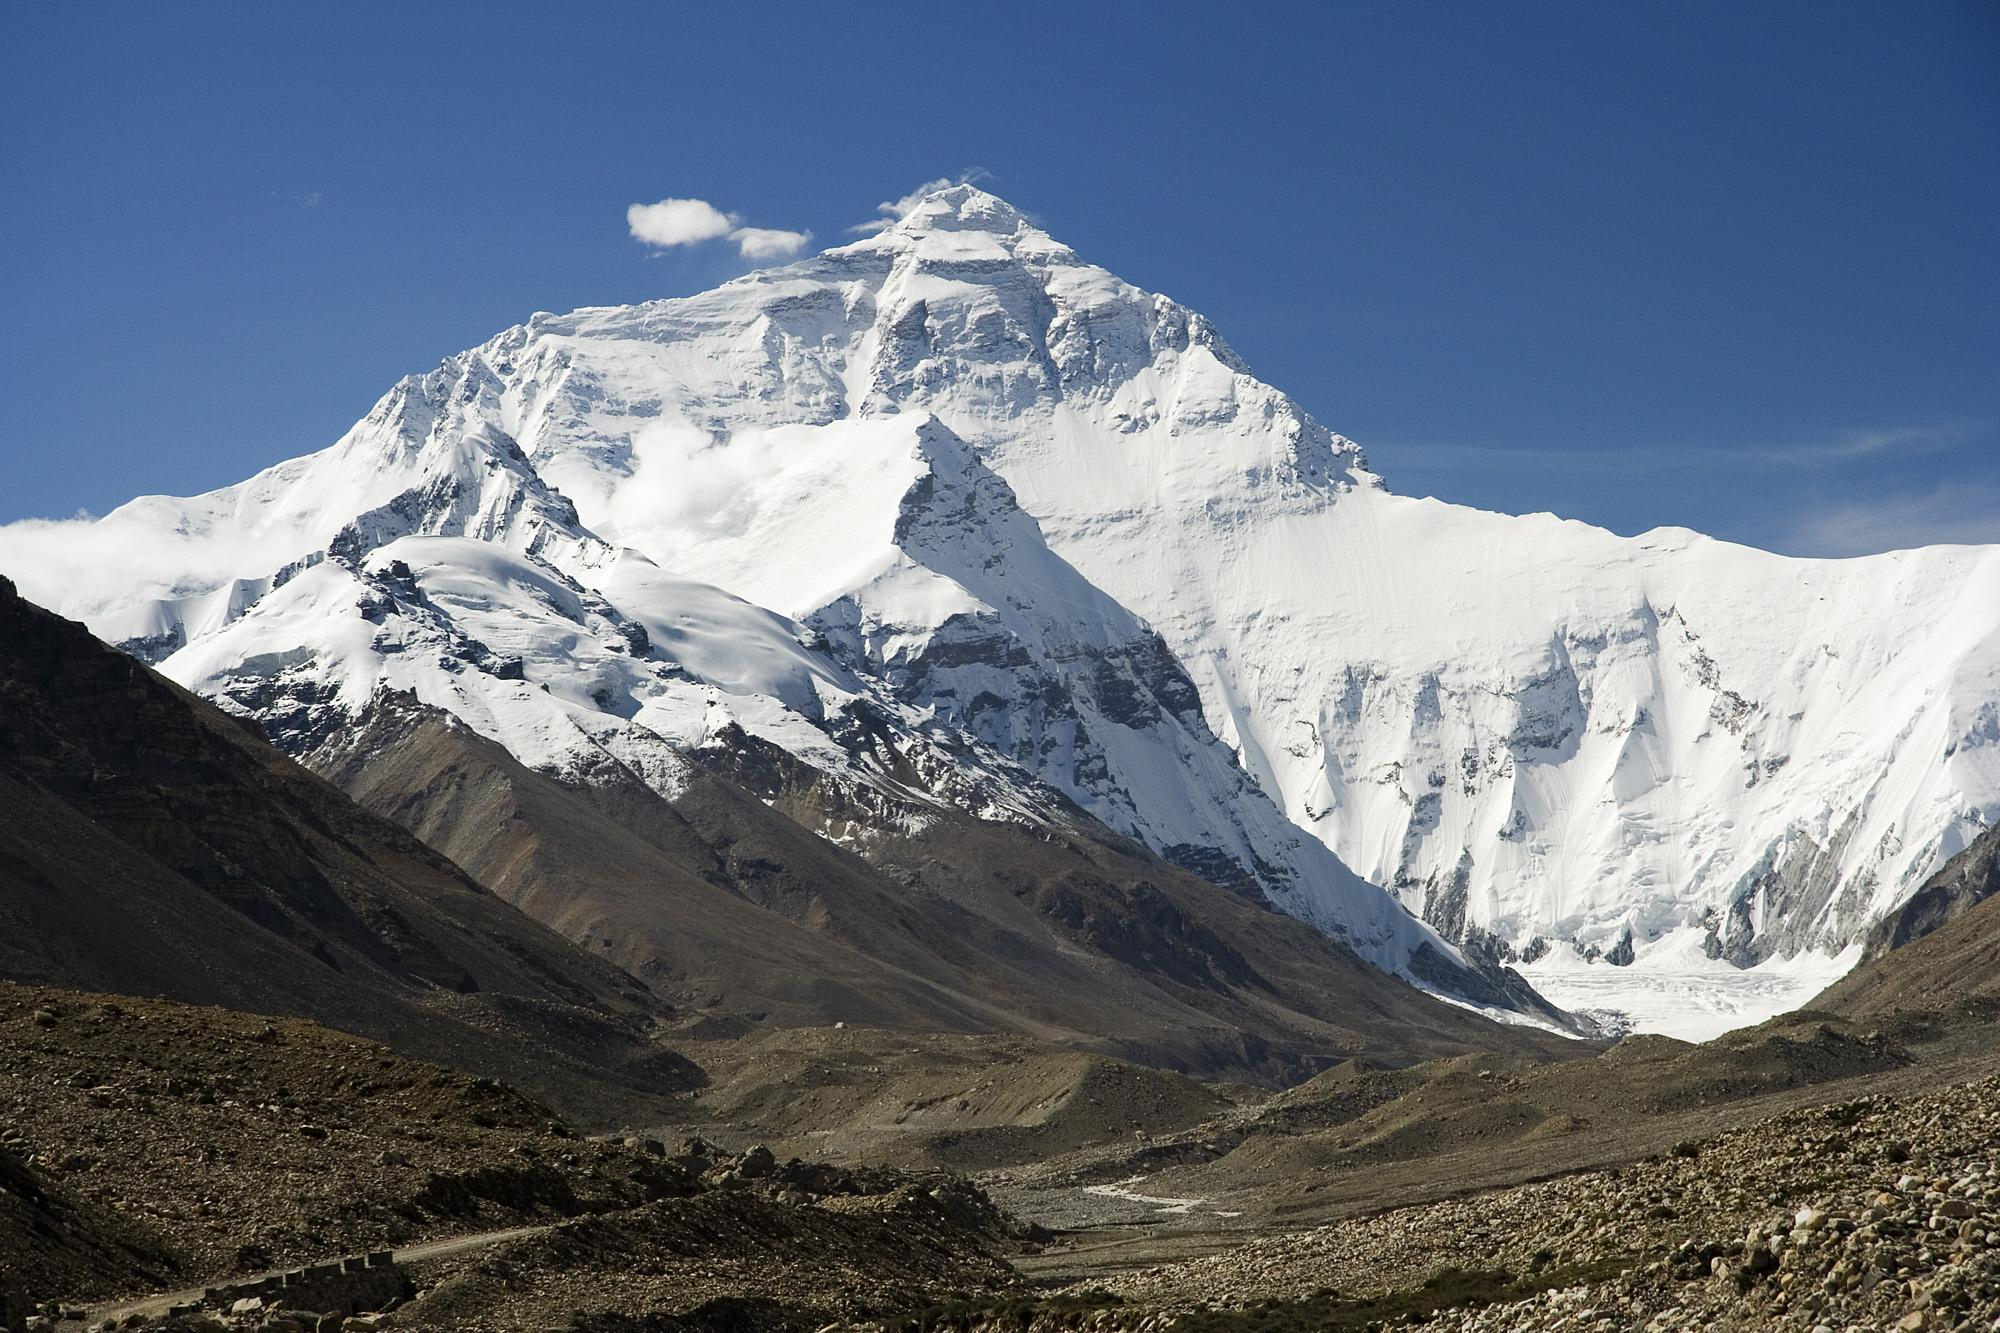


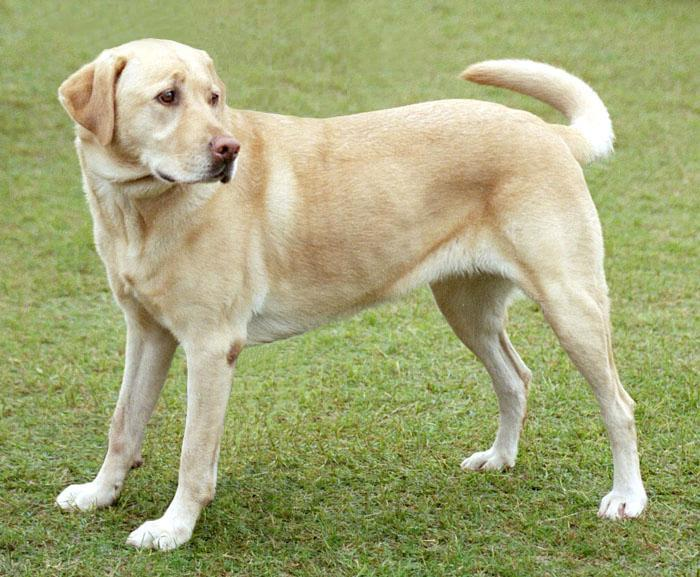

In [14]:
for query, results in retrieval_results.items():
    display_results(query, results)

## Keyword search vs. semantic search

The table below compares what each approach returns when you search for the same term.

In [15]:
def keyword_search(query: str, corpus: list[dict[str, Any]]) -> list[str]:
    """Returns filenames that contain the query string (case-insensitive)."""
    query_lower = query.lower()
    return [
        item["filename"]
        for item in corpus
        if query_lower in item["filename"].lower()
    ]


# Compare keyword vs. semantic search for a few representative terms.
comparison_queries = [
    ("a fluffy cat resting", "cat"),
    ("a dog running in a field", "dog"),
    ("beautiful mountain scenery", "mountain"),
    ("the vast ocean and marine life", "ocean"),
    ("a starry night sky", "space"),
    ("a fast sports car", "bird")
]

header = f"{'Descriptive Query':<32}  {'Keyword matches':<22}  {'Top semantic match (score)'}"
print(header)
print("-" * len(header))

for desc_q, kw_term in comparison_queries:
    kw_hits = keyword_search(kw_term, indexed_corpus) or ["(none)"]
    sem_results = search_similar_content(desc_q, indexed_corpus, top_k=1)
    sem_top = f"{sem_results[0]['filename']} ({sem_results[0]['score']:.4f})" if sem_results else "(none)"
    print(f"{desc_q:<32}  {', '.join(kw_hits):<22}  {sem_top}")

Descriptive Query                 Keyword matches         Top semantic match (score)
------------------------------------------------------------------------------------
a fluffy cat resting              cat_image.png           dog_picture.jpg (0.6800)
a dog running in a field          dog_picture.jpg         cat_image.png (0.6710)
beautiful mountain scenery        mountain_climbing.txt   ocean_view.jpg (0.6784)
the vast ocean and marine life    ocean_view.jpg          space_facts.txt (0.7908)
a starry night sky                space_facts.txt         mountain_climbing.txt (0.7686)
a fast sports car                 bird_song.txt           bird_song.txt (0.7794)


## Summary

In this notebook you:

- Initialised the `google-genai` SDK and configured the `gemini-embedding-2` multimodal embedding model.
- Built a mixed dataset of images and text files with intentionally misleading filenames.
- Generated embeddings for each file and stored them in an in-memory corpus.
- Queried the corpus with natural language and retrieved semantically relevant results — including images — that keyword search would have missed.
- Compared keyword search with semantic search side-by-side to illustrate the difference.

The core insight is that `gemini-embedding-2` maps text and images into a **shared vector space**, so a text query like "dog" can surface an image of a dog saved as `cat_image.png`, purely based on content meaning rather than filename.

### Real-world applications

- **Image search by description** — retrieve images using natural language, even without descriptive tags.
- **Cross-modal document retrieval** — find text documents by querying with an image, or vice versa.
- **Digital asset management** — organise and search large mixed-media libraries efficiently.
- **Recommendation systems** — surface semantically related content across different media types.

## Next steps

### Useful API references

- [`gemini-embedding-2` model documentation](https://ai.google.dev/gemini-api/docs/models/gemini#gemini-embedding)
- [`client.models.embed_content` API reference](https://ai.google.dev/api/embeddings)
- [Embedding task types](https://ai.google.dev/gemini-api/docs/embeddings#task-types)

### Related examples

- [Embeddings quickstart](../quickstarts/Embeddings.ipynb)
- [Document search with embeddings](../examples/Search_reranking_using_embeddings.ipynb)
